### EDA `Fraud Transaction Dataset`

### Import neccsary library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Reading Data

In [2]:
customer_profiles = pd.read_csv('full dataset with brief/customer_profiles.csv')
fraudulent_transactions = pd.read_csv('full dataset with brief/synthetic_fraud_transactions.csv')
terminal_profiles = pd.read_csv('full dataset with brief/terminal_profiles.csv')

In [3]:
customer_profiles.head()

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals
0,0,54.881350,71.518937,62.262521,31.131260,2.179533,78
1,1,42.365480,64.589411,46.570785,23.285393,3.567092,85
2,2,96.366276,38.344152,80.213879,40.106939,2.115580,70
3,3,56.804456,92.559664,11.748426,5.874213,0.348517,70
4,4,2.021840,83.261985,78.924891,39.462446,3.480049,65


In [4]:
fraudulent_transactions.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [5]:
terminal_profiles.head()

,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,41.702200,72.032449
1,1,0.011437,30.233257
2,2,14.675589,9.233859
3,3,18.626021,34.556073
4,4,39.676747,53.881673


### Drawing simple level visualization `Customer data`

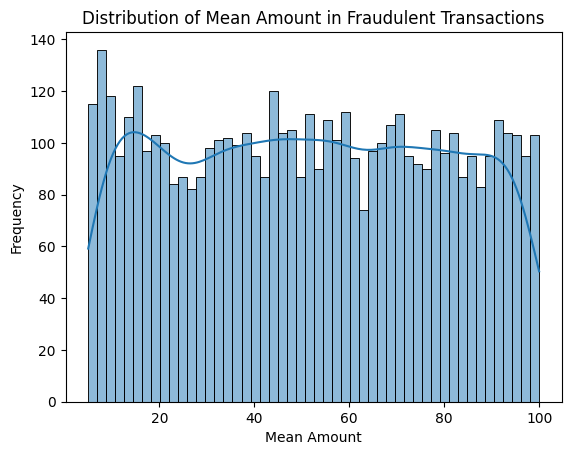

In [6]:
#draw mean_amount distribution
sns.histplot(customer_profiles['mean_amount'], bins=50, kde=True)
plt.title('Distribution of Mean Amount in Fraudulent Transactions')
plt.xlabel('Mean Amount')
plt.ylabel('Frequency')
plt.show()

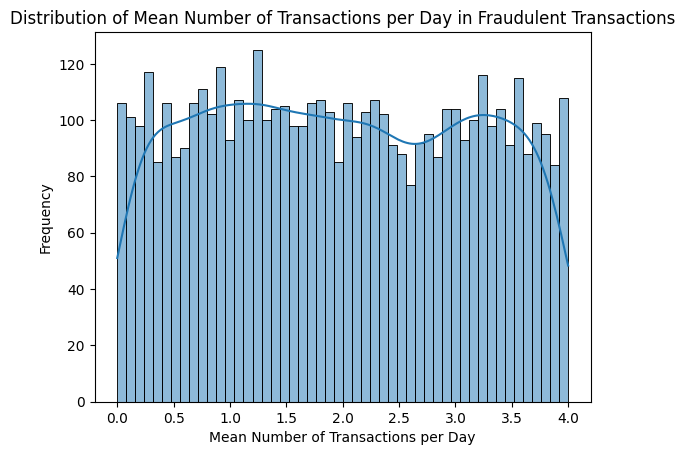

In [10]:
#draw mean_nb_tx_per_day distribution
sns.histplot(customer_profiles['mean_nb_tx_per_day'], bins=50, kde=True)
plt.title('Distribution of Mean Number of Transactions per Day in Fraudulent Transactions')
plt.xlabel('Mean Number of Transactions per Day')
plt.ylabel('Frequency')
plt.show()

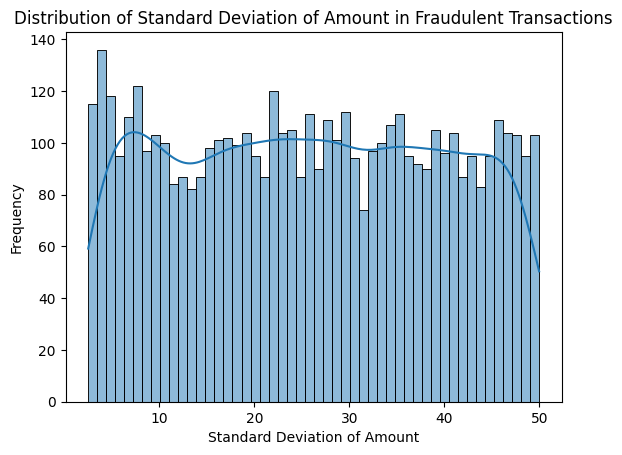

In [12]:
#draw std_amount distribution
sns.histplot(customer_profiles['std_amount'], bins=50, kde=True)
plt.title('Distribution of Standard Deviation of Amount in Fraudulent Transactions')
plt.xlabel('Standard Deviation of Amount')
plt.ylabel('Frequency')
plt.show()

In [3]:
#draw highest np_terminals vs x,y location using plotly
import plotly.express as px
fig = px.scatter(customer_profiles, x='x_customer_id', y='y_customer_id', size='nb_terminals', color='nb_terminals',
                 title='Terminal Profiles: Number of Transactions by Location',
                 labels={'x': 'X Coordinate', 'y': 'Y Coordinate', 'nb_tx': 'Number of Transactions'},
                 size_max=15, color_continuous_scale='Viridis')
fig.show()


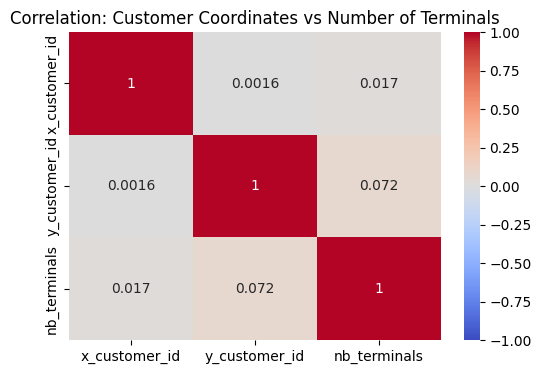

In [4]:
# 1. GEOGRAPHICAL & LOCATION INSIGHTS
plt.figure(figsize=(6, 4))

# Calculate correlation between spatial location and accessible terminals
geo_cols = ['x_customer_id', 'y_customer_id', 'nb_terminals']
geography_corr = customer_profiles[geo_cols].corr()

# Plot the heatmap
sns.heatmap(geography_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation: Customer Coordinates vs Number of Terminals")
plt.show()

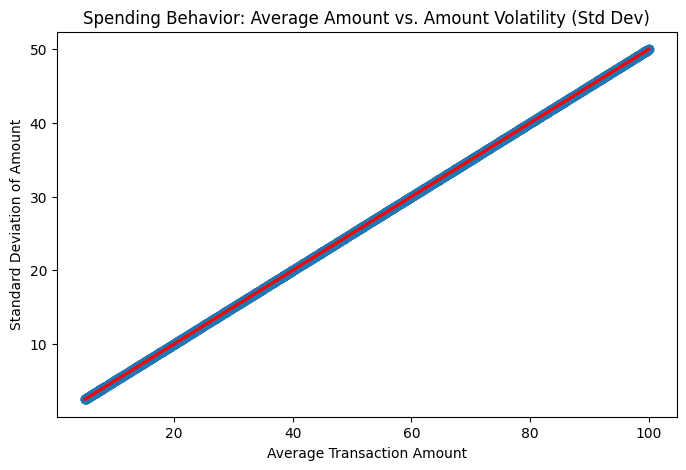

Correlation between Average Amount and Std Amount: 1.0000

Customer counts by spending tier:
spending_tier
Low       1667
High      1667
Medium    1666
Name: count, dtype: int64


In [5]:
# 2. SPENDING BEHAVIOR INSIGHTS
plt.figure(figsize=(8, 5))

# Scatter plot with regression line to see the relationship
sns.regplot(data=customer_profiles, x='mean_amount', y='std_amount', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Spending Behavior: Average Amount vs. Amount Volatility (Std Dev)")
plt.xlabel("Average Transaction Amount")
plt.ylabel("Standard Deviation of Amount")
plt.show()

# Calculate Pearson correlation
amount_corr = customer_profiles['mean_amount'].corr(customer_profiles['std_amount'])
print(f"Correlation between Average Amount and Std Amount: {amount_corr:.4f}")

# Segment customers into 3 behavioral tiers (Low, Medium, High spenders)
customer_profiles['spending_tier'] = pd.qcut(customer_profiles['mean_amount'], q=3, labels=['Low', 'Medium', 'High'])
print("\nCustomer counts by spending tier:")
print(customer_profiles['spending_tier'].value_counts())

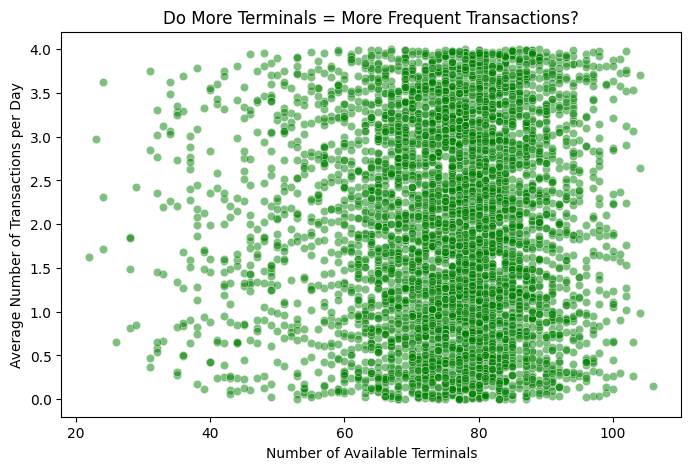

Correlation between Terminals and Daily Transactions: 0.0159

Top 5 Most Active Customers:


,CUSTOMER_ID,mean_nb_tx_per_day,mean_amount,nb_terminals
2040,2040,3.999912,72.139785,67
840,840,3.999725,58.428173,89
1953,1953,3.998834,79.116988,86
154,154,3.997112,42.739391,78
2815,2815,3.994735,68.591641,94


In [6]:
# 3. TRANSACTION FREQUENCY INSIGHTS
plt.figure(figsize=(8, 5))

# Scatter plot comparing available terminals to daily transactions
sns.scatterplot(data=customer_profiles, x='nb_terminals', y='mean_nb_tx_per_day', alpha=0.5, color='green')
plt.title("Do More Terminals = More Frequent Transactions?")
plt.xlabel("Number of Available Terminals")
plt.ylabel("Average Number of Transactions per Day")
plt.show()

# Check correlation between terminal availability and frequency
freq_corr = customer_profiles['nb_terminals'].corr(customer_profiles['mean_nb_tx_per_day'])
print(f"Correlation between Terminals and Daily Transactions: {freq_corr:.4f}")

# Find the top 5 most frequently transacting customers
top_active = customer_profiles.sort_values(by='mean_nb_tx_per_day', ascending=False).head()
print("\nTop 5 Most Active Customers:")
display(top_active[['CUSTOMER_ID', 'mean_nb_tx_per_day', 'mean_amount', 'nb_terminals']])

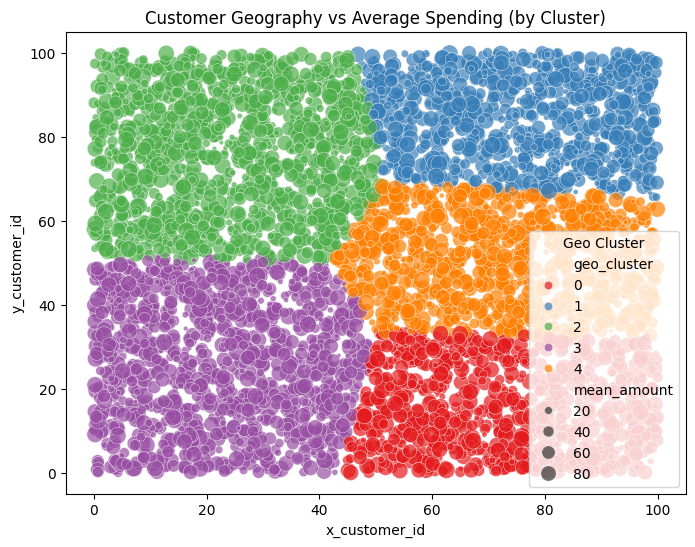

Average Spending per Geographical Cluster:
geo_cluster
1    52.671089
4    52.367771
0    51.557075
3    51.455769
2    51.285671
Name: mean_amount, dtype: float64


In [7]:
from sklearn.cluster import KMeans

# Find dense customer regions (using K-Means clustering on X,Y coordinates)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
customer_profiles['geo_cluster'] = kmeans.fit_predict(customer_profiles[['x_customer_id', 'y_customer_id']])

# Plot the geographical clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_profiles, x='x_customer_id', y='y_customer_id', 
                hue='geo_cluster', palette='Set1', size='mean_amount', sizes=(10, 150), alpha=0.7)
plt.title("Customer Geography vs Average Spending (by Cluster)")
plt.legend(title='Geo Cluster')
plt.show()

# See which region has the highest average spending
cluster_summary = customer_profiles.groupby('geo_cluster')['mean_amount'].mean().sort_values(ascending=False)
print("Average Spending per Geographical Cluster:")
print(cluster_summary)

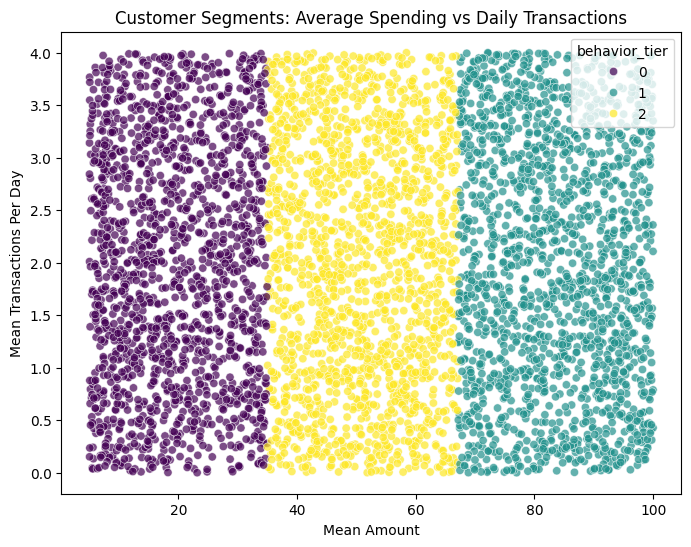

Average behavior per tier:


,mean_amount,mean_nb_tx_per_day
behavior_tier,,
0,19.238924,1.980243
1,83.487687,1.977851
2,50.875422,1.974735


In [8]:
# Cluster customers purely based on financial behavior 
X_behavior = customer_profiles[['mean_amount', 'mean_nb_tx_per_day']]

# We'll try 3 clusters to represent Low, Medium, and High activity tiers
kmeans_tier = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_profiles['behavior_tier'] = kmeans_tier.fit_predict(X_behavior)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_profiles, x='mean_amount', y='mean_nb_tx_per_day', 
                hue='behavior_tier', palette='viridis', alpha=0.7)
plt.title("Customer Segments: Average Spending vs Daily Transactions")
plt.xlabel("Mean Amount")
plt.ylabel("Mean Transactions Per Day")
plt.show()

print("Average behavior per tier:")
display(customer_profiles.groupby('behavior_tier')[['mean_amount', 'mean_nb_tx_per_day']].mean())

### Fraudlant csv data

### `inner join` merge

In [6]:
#perform merge inner join between fraudulent_transactions and customer_profiles on CUSTOMER_ID
merged_data = pd.merge(fraudulent_transactions, customer_profiles, on='CUSTOMER_ID', how='inner')
print("Merged Data Sample:")
display(merged_data.head())

Merged Data Sample:


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,14.186726,36.180124,41.255735,20.627868,3.789234,74
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,70.297680,31.886146,85.494893,42.747447,3.946423,88
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,96.366276,38.344152,80.213879,40.106939,2.115580,70
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0,98.601551,9.299024,55.707112,27.853556,3.414286,47
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0,64.112433,62.042110,55.675654,27.837827,3.030989,82


In [7]:
merged_data["TX_FRAUD_SCENARIO"].value_counts()

TX_FRAUD_SCENARIO
0    1739474
2       9077
3       4631
1        973
Name: count, dtype: int64

In [8]:
fraude = len(merged_data[merged_data["TX_FRAUD"] ==1])
non_fraude = len(merged_data[merged_data["TX_FRAUD"] ==0])
print(f"Number of Fraudulent Transactions: {fraude}")
print(f"Number of Non-Fraudulent Transactions: {non_fraude}")

Number of Fraudulent Transactions: 14681
Number of Non-Fraudulent Transactions: 1739474


### Check Data Imabalance

/tmp/ipykernel_5121/1523904738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=merged_data['TX_FRAUD'].value_counts().index, y=merged_data['TX_FRAUD'].value_counts().values, palette='Set2')


<Axes: xlabel='TX_FRAUD'>

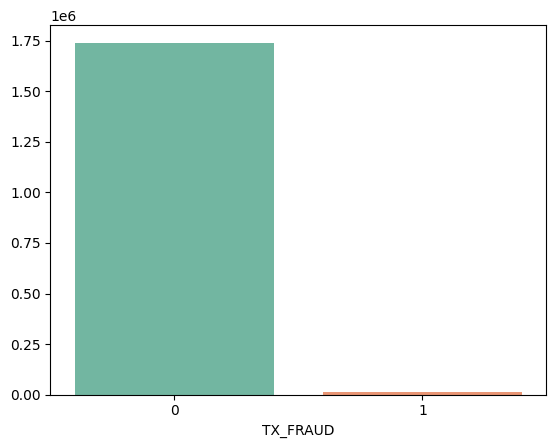

In [18]:
#draw data impalance
sns.barplot(x=merged_data['TX_FRAUD'].value_counts().index, y=merged_data['TX_FRAUD'].value_counts().values, palette='Set2')

### EDA `Bivariate` 

In [9]:
#knowing number that represents the number of fraudulent transactions for each customer
fraud_counts = merged_data['CUSTOMER_ID'].value_counts().reset_index()
fraud_counts.columns = ['CUSTOMER_ID', 'fraud_count']
print("\nNumber of Fraudulent Transactions per Customer:")
display(fraud_counts.head())


Number of Fraudulent Transactions per Customer:


,CUSTOMER_ID,fraud_count
0,382,767
1,3864,762
2,2891,761
3,775,754
4,1411,752


### Check Distrbution of Fraud Per customer we find that this data is normal distruption 

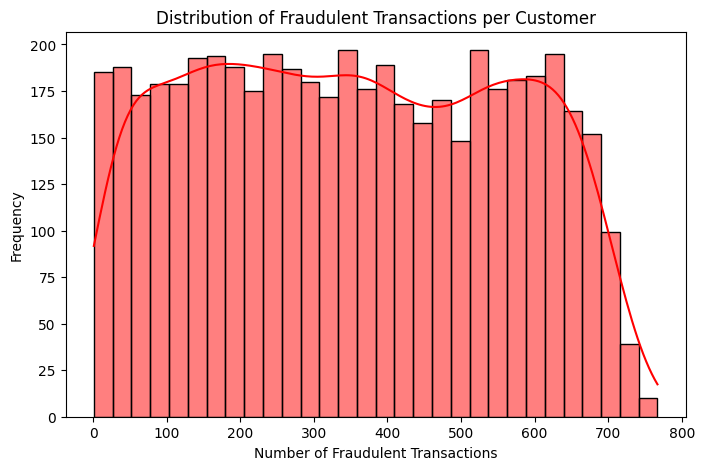

In [10]:
#draw distribution of fraud counts per customer
plt.figure(figsize=(8, 5))
sns.histplot(fraud_counts['fraud_count'], bins=30, kde=True, color='red')
plt.title("Distribution of Fraudulent Transactions per Customer")
plt.xlabel("Number of Fraudulent Transactions")
plt.ylabel("Frequency")
plt.show()

### We can see that there is high transaction amount for faudlant tranaction

/tmp/ipykernel_5121/1969072684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data, x='TX_FRAUD', y='TX_AMOUNT', palette='Set2')


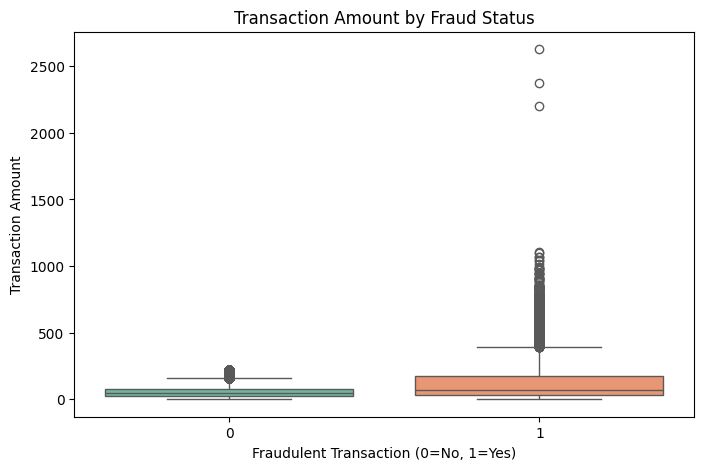

In [10]:
#draw ralationship between fraud (0/1) and transaction amount
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_data, x='TX_FRAUD', y='TX_AMOUNT', palette='Set2')
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraudulent Transaction (0=No, 1=Yes)")
plt.ylabel("Transaction Amount")
plt.show()

### see transaction time effect factor

/tmp/ipykernel_5121/3982168848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data, x='TX_FRAUD', y='TX_TIME_SECONDS', palette='Set3')


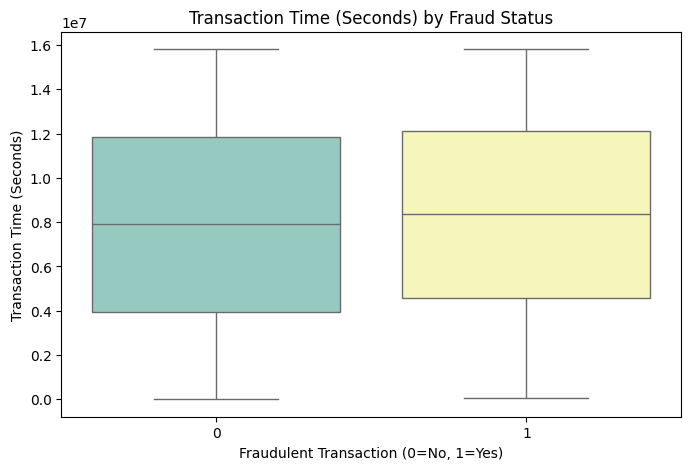

In [11]:
#see relationship between TX_TIME_SECONDS and TX_FRAUD
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_data, x='TX_FRAUD', y='TX_TIME_SECONDS', palette='Set3')
plt.title("Transaction Time (Seconds) by Fraud Status")
plt.xlabel("Fraudulent Transaction (0=No, 1=Yes)")
plt.ylabel("Transaction Time (Seconds)")
plt.show()

### Try ti find any seasonal patern for fraualnt transaction `conclusion` that we did't find any transaction seasonal pattern

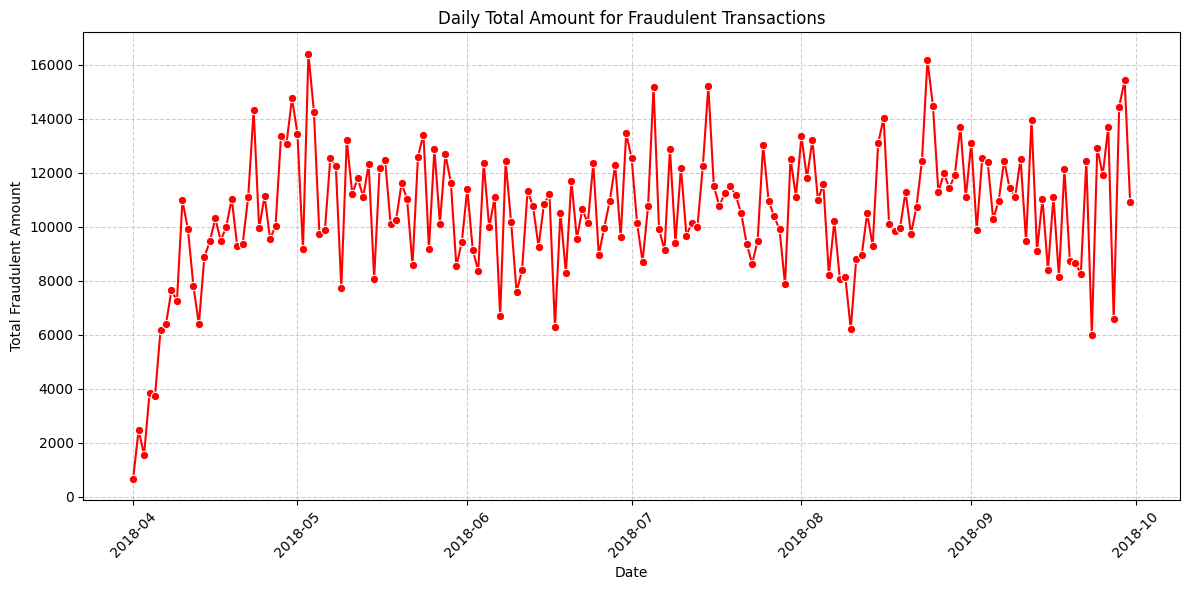

In [14]:
#draw time series for TX_DATETIME across TX_AMOUNT for fraudlant Transactions dailey aggregation
# Filter for fraudulent transactions only
fraud_data = merged_data[merged_data['TX_FRAUD'] == 1].copy()

# Ensure TX_DATETIME is a datetime object
fraud_data['TX_DATETIME'] = pd.to_datetime(fraud_data['TX_DATETIME'])

# Extract just the date for daily aggregation
fraud_data['TX_DATE'] = fraud_data['TX_DATETIME'].dt.date

# Aggregate the transaction amounts daily (you can use .sum() or .mean())
daily_fraud_amount = fraud_data.groupby('TX_DATE')['TX_AMOUNT'].sum().reset_index()

# Draw the time series plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_fraud_amount, x='TX_DATE', y='TX_AMOUNT', color='red', marker='o')

plt.title("Daily Total Amount for Fraudulent Transactions")
plt.xlabel("Date")
plt.ylabel("Total Fraudulent Amount")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Decompose time series to see pattern 

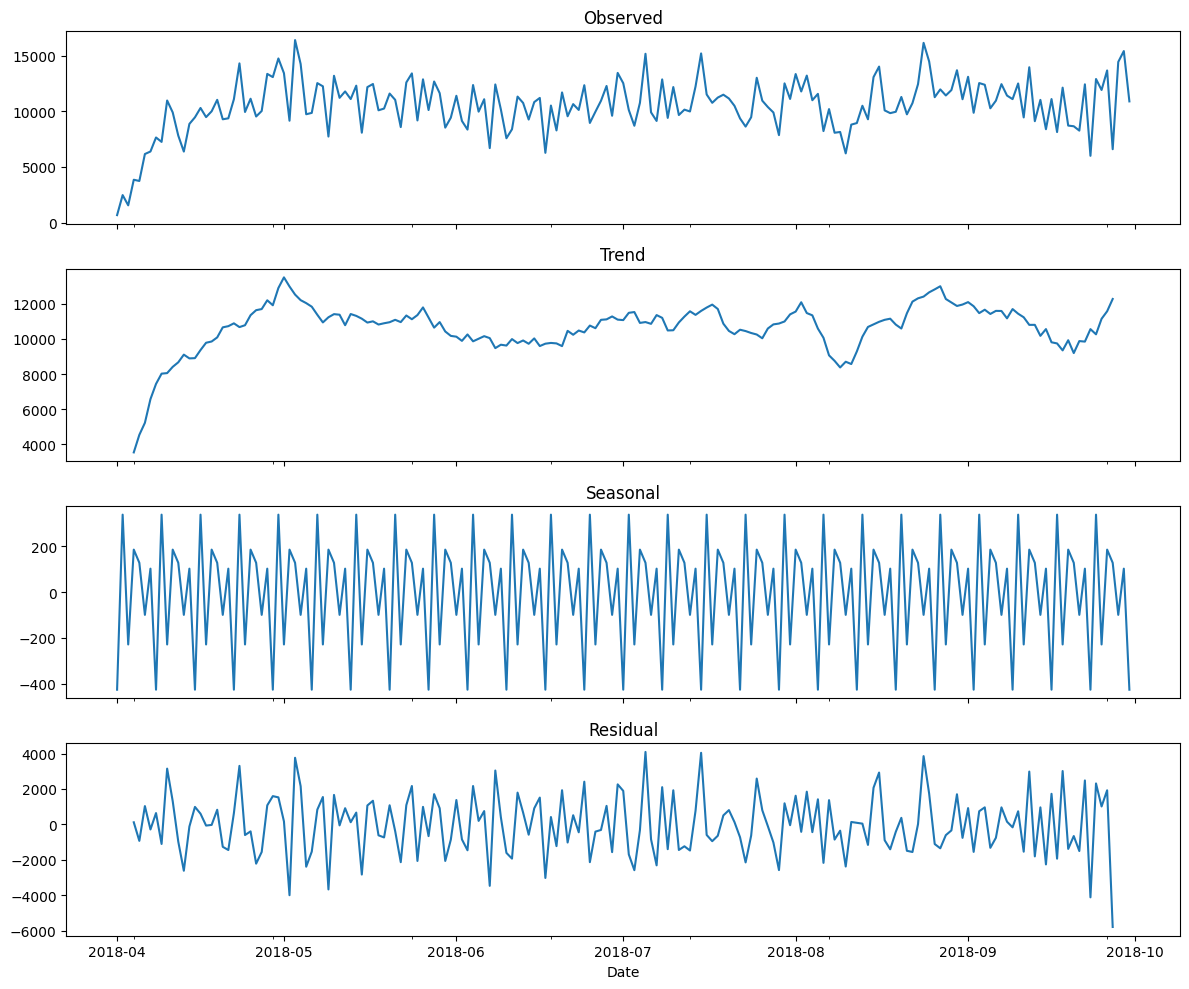

In [15]:
# decompose seasonallity of daily fraudulent amount using statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
# Set the date as the index for time series analysis
daily_fraud_amount.set_index('TX_DATE', inplace=True)
# Decompose the time series (using additive model)  
decomposition = seasonal_decompose(daily_fraud_amount['TX_AMOUNT'], model='additive', period=7)  # Assuming weekly seasonality
# Plot the decomposed components
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.xlabel("Date")
plt.tight_layout()
plt.show()

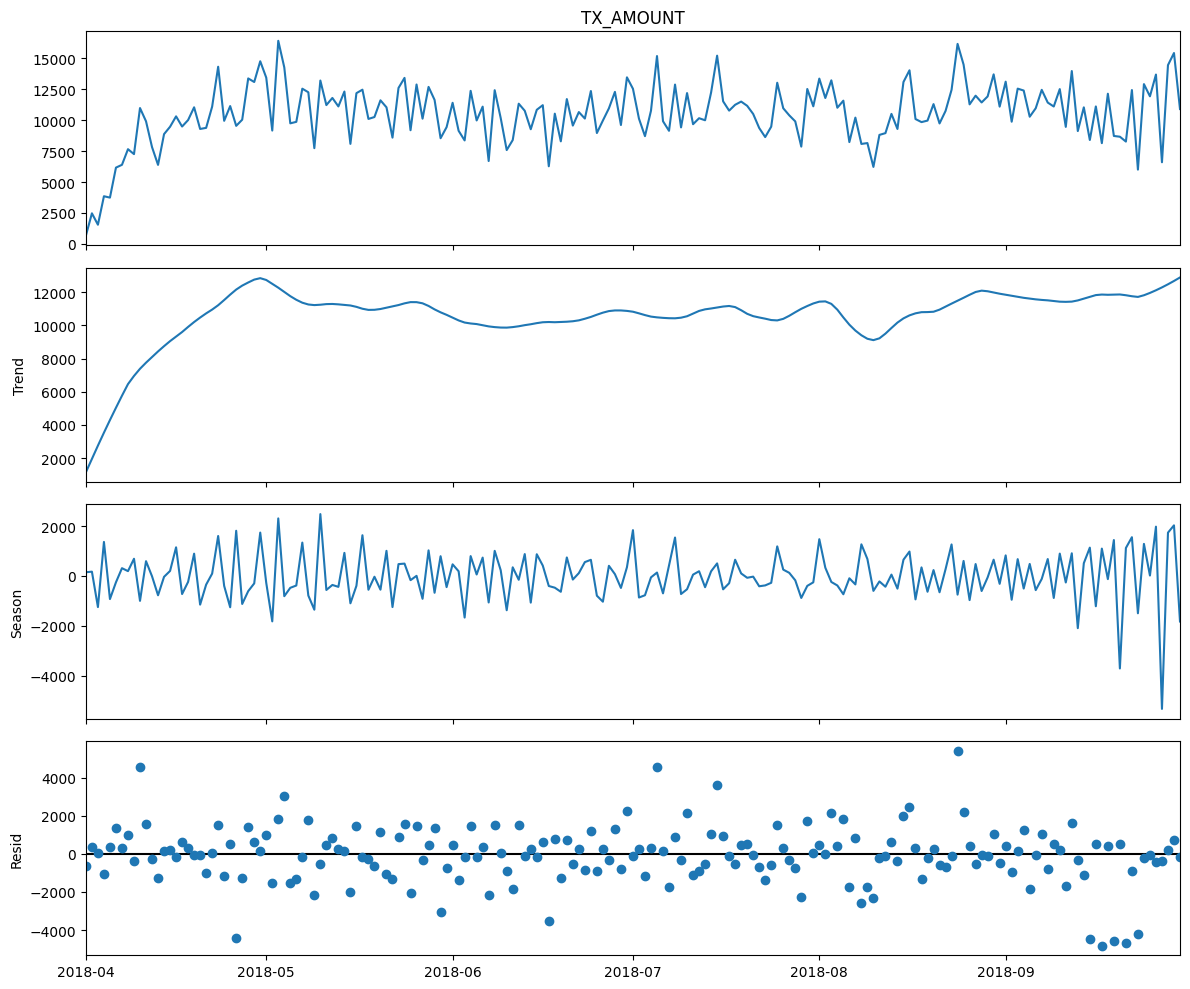

In [16]:
# STL Decomposition (Seasonal and Trend decomposition using Loess): 
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Using STL (Seasonal and Trend decomposition using Loess)
# strict period=7 is used to check weekly seasonality, and robust=True reduces the influence of outliers
stl_model = STL(daily_fraud_amount['TX_AMOUNT'], period=7, robust=True)
stl_result = stl_model.fit()

# Plot the decomposed components
fig = stl_result.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

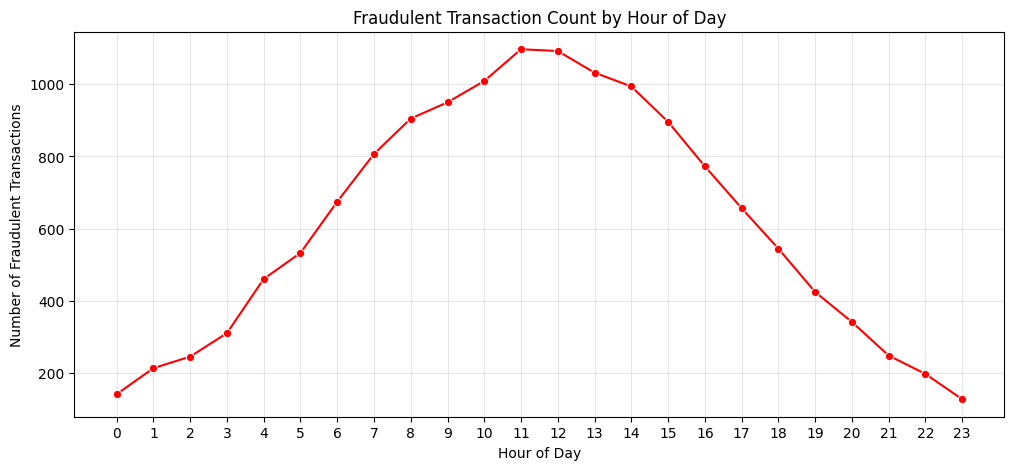

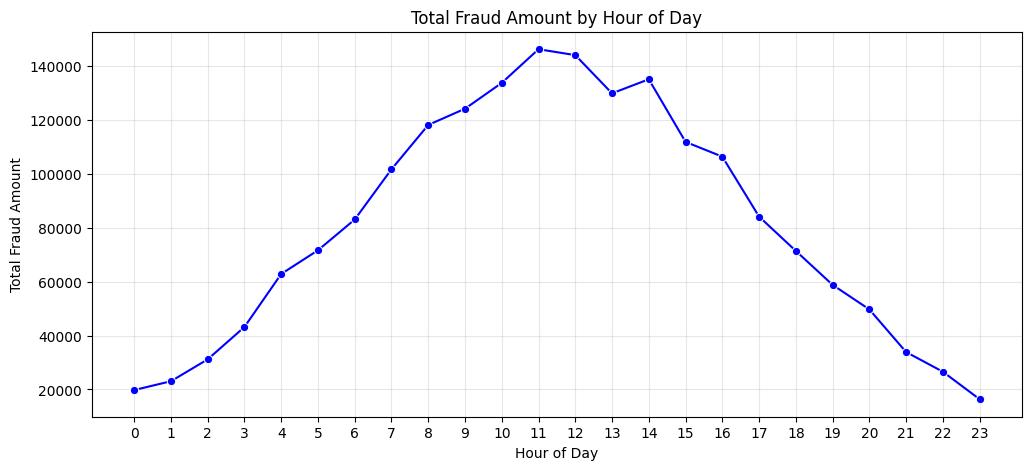

In [11]:
# Filter fraudulent transactions and parse the datetime column
fraud_data = merged_data[merged_data['TX_FRAUD'] == 1].copy()
fraud_data['TX_DATETIME'] = pd.to_datetime(fraud_data['TX_DATETIME'])

# Extract hour of day
fraud_data['TX_HOUR'] = fraud_data['TX_DATETIME'].dt.hour

# Aggregate fraud count and total amount by hour
hourly_fraud = fraud_data.groupby('TX_HOUR').agg(
    fraud_count=('TX_FRAUD', 'size'),
    total_amount=('TX_AMOUNT', 'sum')
).reset_index()

# Plot fraud count by hour
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_fraud, x='TX_HOUR', y='fraud_count', marker='o', color='red')
plt.title("Fraudulent Transaction Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

# Plot fraud amount by hour
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_fraud, x='TX_HOUR', y='total_amount', marker='o', color='blue')
plt.title("Total Fraud Amount by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Fraud Amount")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

### see top 10 fraudlant ID trying to study this

In [4]:
#Quantify most terminal ID that cause Fraud
top_fraud_terminals = merged_data[merged_data['TX_FRAUD'] == 1]['TERMINAL_ID'].value_counts().head(10)
print("Top 10 Terminals Associated with Fraudulent Transactions:")
display(top_fraud_terminals)


Top 10 Terminals Associated with Fraudulent Transactions:


TERMINAL_ID
293     85
1244    72
3644    59
7054    50
4692    48
5158    47
1783    47
9251    47
596     46
4865    45
Name: count, dtype: int64

In [ ]:

terminal_profiles[terminal_profiles['TERMINAL_ID'].isin(top_fraud_terminals.index)]

,TERMINAL_ID,x_terminal_id,y_terminal_id
293,293,80.769841,35.353486
596,596,87.858786,19.083936
1244,1244,6.813006,55.125665
1783,1783,73.048867,2.352791
3644,3644,87.021087,57.166806
4692,4692,24.164731,33.244023
4865,4865,43.929215,87.472641
5158,5158,25.635076,34.881345
7054,7054,1.509933,0.826243
9251,9251,1.017659,42.189958


### see location of top fraudlant

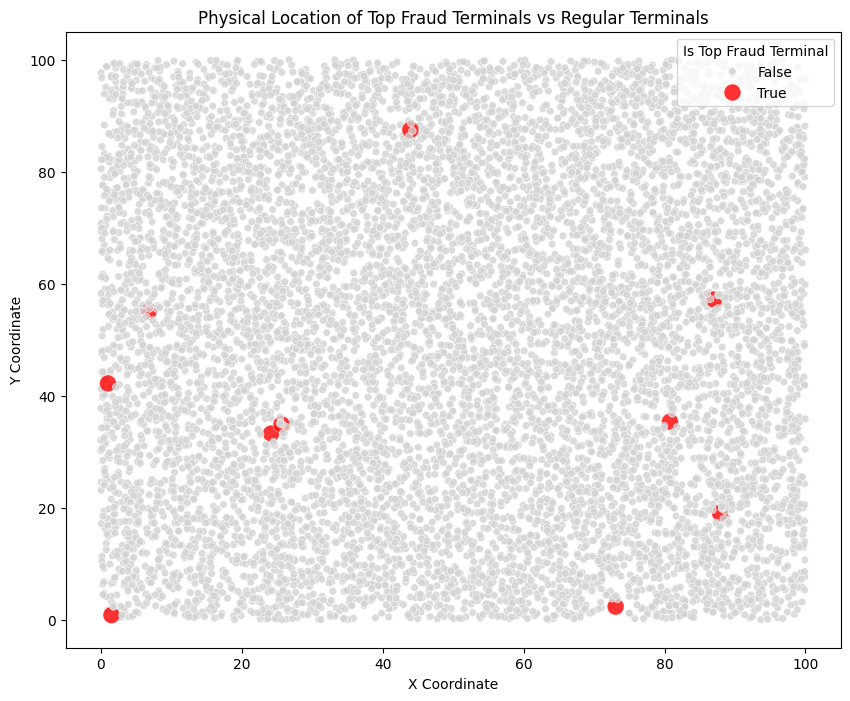

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Plot all terminals in light gray, and the top fraud terminals in bright red
sns.scatterplot(
    data=terminal_profiles, 
    x='x_terminal_id',    # Adjust if your coordinate columns are named differently
    y='y_terminal_id', 
    hue='is_top_fraud', 
    palette={False: 'lightgrey', True: 'red'},
    size='is_top_fraud',
    sizes={False: 30, True: 150}, # Make the fraud terminals visually larger
    alpha=0.8
)

plt.title("Physical Location of Top Fraud Terminals vs Regular Terminals")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(title="Is Top Fraud Terminal")
plt.show()

In [8]:
merged_data

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,14.186726,36.180124,41.255735,20.627868,3.789234,74
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,70.297680,31.886146,85.494893,42.747447,3.946423,88
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,96.366276,38.344152,80.213879,40.106939,2.115580,70
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0,98.601551,9.299024,55.707112,27.853556,3.414286,47
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0,64.112433,62.042110,55.675654,27.837827,3.030989,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2018-09-30 23:56:36,161,655,54.24,15810996,182,0,0,38.033518,14.780868,70.068772,35.034386,2.627048,90
1754151,1754151,2018-09-30 23:57:38,4342,6181,1.23,15811058,182,0,0,49.864638,62.018204,23.781850,11.890925,3.231563,74
1754152,1754152,2018-09-30 23:58:21,618,1502,6.62,15811101,182,0,0,96.673774,53.470817,7.338380,3.669190,2.479088,68
1754153,1754153,2018-09-30 23:59:52,4056,3067,55.40,15811192,182,0,0,71.330970,79.941000,88.115044,44.057522,1.835809,84


### see time in seconde for fraudlant transaction

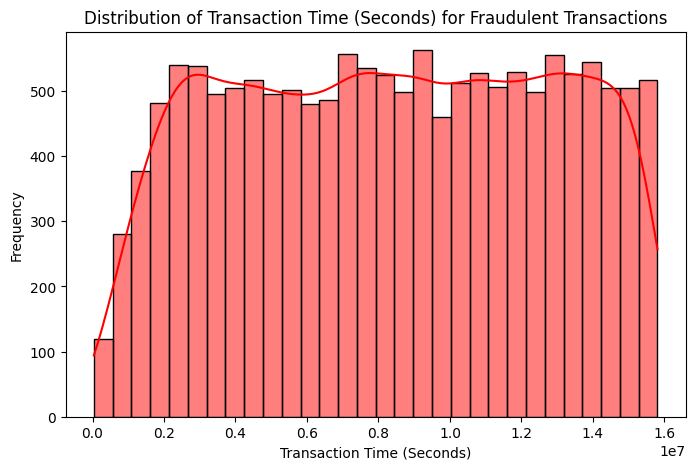

In [9]:
#draw distribution of TX_TIME_SECONDS for fraudulent transactions
plt.figure(figsize=(8, 5))
sns.histplot(merged_data[merged_data['TX_FRAUD'] == 1]['TX_TIME_SECONDS'], bins=30, kde=True, color='red')
plt.title("Distribution of Transaction Time (Seconds) for Fraudulent Transactions")
plt.xlabel("Transaction Time (Seconds)")
plt.ylabel("Frequency")
plt.show()

### see distance X,y for fraudlant vs non-fraudlant

/tmp/ipykernel_16867/953697401.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data, x='TX_FRAUD', y='distance_to_terminal', palette='Set2')


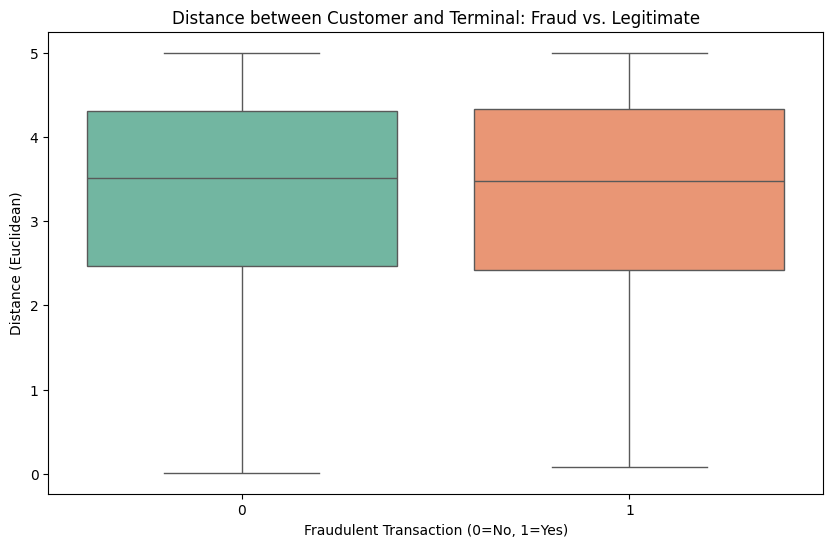

Average distance to terminal by fraud status:
TX_FRAUD
0    3.309016
1    3.302264
Name: distance_to_terminal, dtype: float64


In [10]:
import numpy as np

# Merge terminal coordinates into the main dataset
merged_data = pd.merge(
    merged_data, 
    terminal_profiles[['TERMINAL_ID', 'x_terminal_id', 'y_terminal_id']], 
    on='TERMINAL_ID', 
    how='left'
)

# Calculate Euclidean distance between customer and terminal
merged_data['distance_to_terminal'] = np.sqrt(
    (merged_data['x_customer_id'] - merged_data['x_terminal_id'])**2 + 
    (merged_data['y_customer_id'] - merged_data['y_terminal_id'])**2
)

# Plot distance distribution: Fraud vs Non-Fraud
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_data, x='TX_FRAUD', y='distance_to_terminal', palette='Set2')
plt.title("Distance between Customer and Terminal: Fraud vs. Legitimate")
plt.xlabel("Fraudulent Transaction (0=No, 1=Yes)")
plt.ylabel("Distance (Euclidean)")
plt.show()

# Print average distances
print("Average distance to terminal by fraud status:")
print(merged_data.groupby('TX_FRAUD')['distance_to_terminal'].mean())

/tmp/ipykernel_16867/1264080880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fraud_only, x='TX_FRAUD_SCENARIO', y='TX_AMOUNT', palette='pastel')


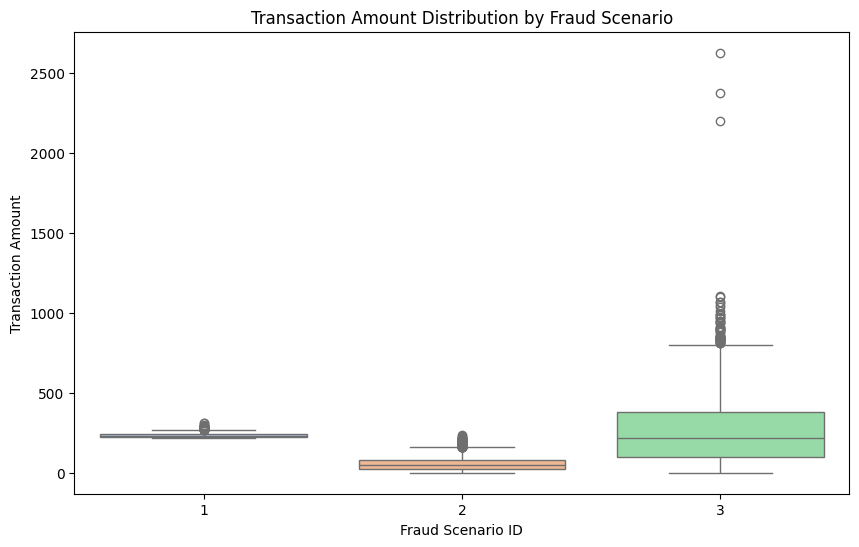

Transaction Amount Summary by Fraud Scenario:


,count,mean,std,min,max
TX_FRAUD_SCENARIO,,,,,
1,973.0,235.317071,14.639319,220.02,310.39
2,9077.0,53.808108,39.771214,0.02,234.69
3,4631.0,260.915148,204.142243,0.10,2628.00


In [11]:
# Filter only fraudulent transactions
fraud_only = merged_data[merged_data['TX_FRAUD'] == 1]

# Plot transaction amount by fraud scenario
plt.figure(figsize=(10, 6))
sns.boxplot(data=fraud_only, x='TX_FRAUD_SCENARIO', y='TX_AMOUNT', palette='pastel')
plt.title("Transaction Amount Distribution by Fraud Scenario")
plt.xlabel("Fraud Scenario ID")
plt.ylabel("Transaction Amount")
plt.show()

# Print summary stats for each scenario
print("Transaction Amount Summary by Fraud Scenario:")
display(fraud_only.groupby('TX_FRAUD_SCENARIO')['TX_AMOUNT'].describe()[['count', 'mean', 'std', 'min', 'max']])

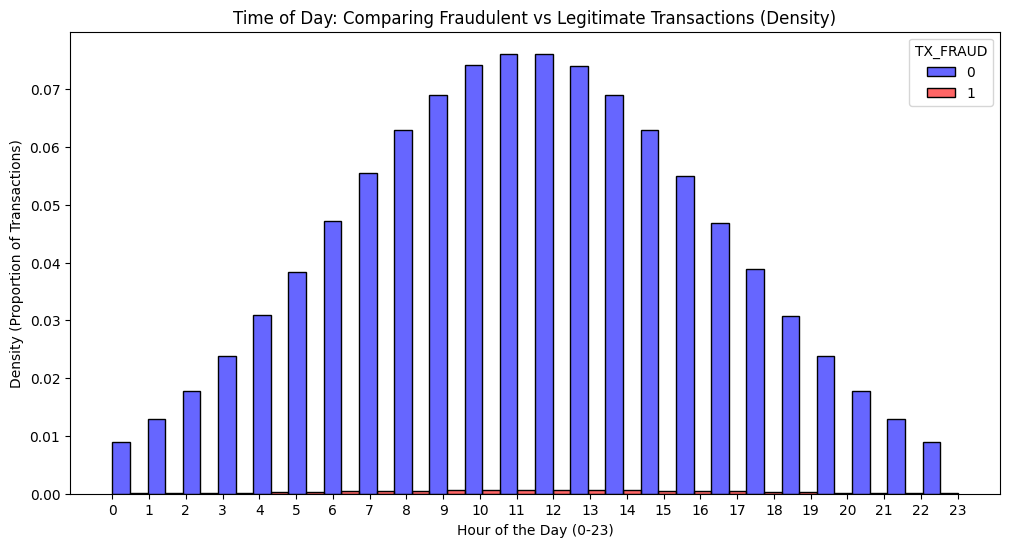

In [12]:
# Ensure TX_DATETIME is datetime type (if not already done)
merged_data['TX_DATETIME'] = pd.to_datetime(merged_data['TX_DATETIME'])

# Extract the hour of the day
merged_data['TX_HOUR'] = merged_data['TX_DATETIME'].dt.hour

# Plot the distribution of transactions by hour for Fraud vs Legitimate
plt.figure(figsize=(12, 6))

# We use density=True (stat='density') because non-fraud massively outnumbers fraud
sns.histplot(
    data=merged_data, 
    x='TX_HOUR', 
    hue='TX_FRAUD', 
    multiple='dodge', 
    stat='density', 
    bins=24, 
    palette={0: 'blue', 1: 'red'},
    alpha=0.6
)

plt.title("Time of Day: Comparing Fraudulent vs Legitimate Transactions (Density)")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Density (Proportion of Transactions)")
plt.xticks(range(0, 24))
plt.show()